<a href="https://colab.research.google.com/github/usman-infinity/Final_For_The_Research_Paper-/blob/main/MODEL%3ECNN_BiGRU_WITH_CITY_GRAPHS_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Training CNN-BiGRU Model...
Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


17452/17452 ━━━━━━━━━━━━━━━━━━━━ 166s 9ms/step - loss: 0.0012 - mae: 0.0234 - val_loss: 3.4350e-04 - val_mae: 0.0125
Epoch 2/20
17452/17452 ━━━━━━━━━━━━━━━━━━━━ 204s 9ms/step - loss: 8.3651e-04 - mae: 0.0195 - val_loss: 4.3254e-04 - val_mae: 0.0136
Epoch 3/20
17452/17452 ━━━━━━━━━━━━━━━━━━━━ 202s 9ms/step - loss: 7.6882e-04 - mae: 0.0183 - val_loss: 3.2004e-04 - val_mae: 0.0114
Epoch 4/20
17452/17452 ━━━━━━━━━━━━━━━━━━━━ 171s 10ms/step - loss: 7.2908e-04 - mae: 0.0178 - val_loss: 3.2368e-04 - val_mae: 0.0118
Epoch 5/20
17452/17452 ━━━━━━━━━━━━━━━━━━━━ 201s 10ms/step - loss: 6.7735e-04 - mae: 0.0172 - val_loss: 0.0011 - val_mae: 0.0288
Epoch 6/20
17452/17452 ━━━━━━━━━━━━━━━━━━━━ 172s 10ms/step - loss: 6.4270e-04 - mae: 0.0167 - val_loss: 5.0935e-04 - val_mae: 0.0167
Epoch 7/20
17452/17452 ━━━━━━━━━━━━━━━━━━━━ 197s 10ms/step - loss: 6.1699e-04 - mae: 0.0164 - val_loss: 3.4287e-04 - val_mae: 0.0128
Epoch 8/20
17452/17452 ━━━━━━━━━━━━━━━━━━━━ 209s 10ms/step - loss: 6.0406e-04 - mae: 0.0161

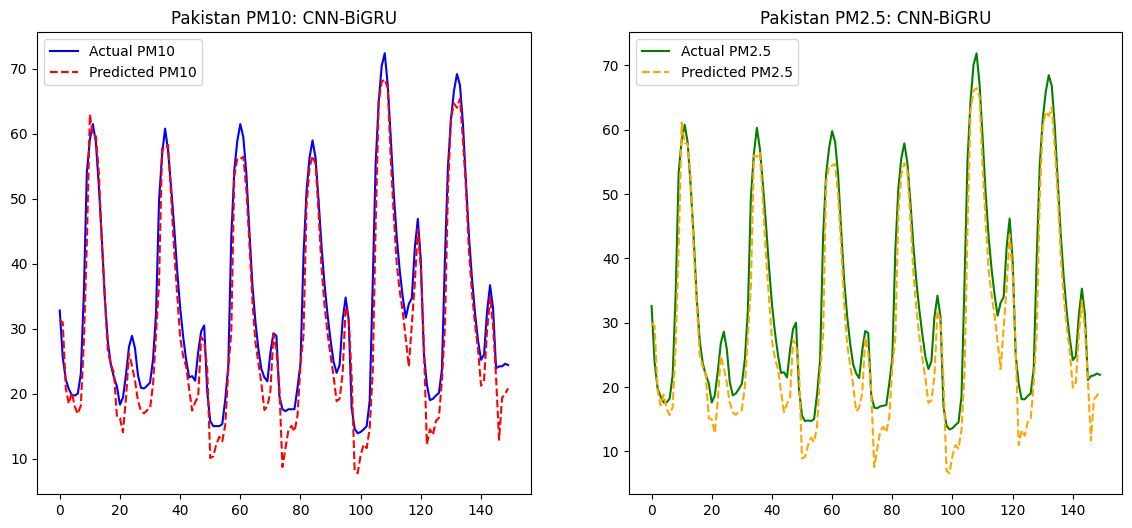

Model saved successfully.
Model loaded successfully.
              City Pollutant    MAE   RMSE      R2
0       Faisalabad      PM10  10.86  15.99  0.9628
1       Faisalabad      PM25  10.95  15.95  0.9627
2        Islamabad      PM10   5.54   7.61  0.9305
3        Islamabad      PM25   6.23   8.17  0.9157
4          Karachi      PM10  19.13  23.02 -0.1818
5          Karachi      PM25   9.63  11.62  0.4002
6           Lahore      PM10   8.05  12.43  0.9607
7           Lahore      PM25   8.29  12.64  0.9594
8           Multan      PM10   8.67  13.63  0.9645
9           Multan      PM25  10.33  14.78  0.9577
10        Peshawar      PM10   5.72   7.89  0.9328
11        Peshawar      PM25   5.41   7.55  0.9366
12          Quetta      PM10  38.87  46.65  0.1262
13          Quetta      PM25   7.54   8.81  0.3637
14  Rahim Yar Khan      PM10   5.52   7.88  0.9475
15  Rahim Yar Khan      PM25   4.89   7.11  0.9585
16      Rawalpindi      PM10   5.54   7.61  0.9305
17      Rawalpindi      PM25 

In [ ]:
# =========================================================
# 🚀 PAKISTAN AIR QUALITY: CNN + BiGRU (LSTM REMOVED)
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, Sequential

# ----------------------------
# 1️⃣ Load & Clean Dataset
# ----------------------------
try:
    # Update filename as per your specific Pakistan dataset file
    df = pd.read_csv("pakistan_air_quality_final_clean.csv")
except:
    from google.colab import files
    uploaded = files.upload()
    df = pd.read_csv(list(uploaded.keys())[0])

# Clean and format columns
df.rename(columns={'pm2_5': 'pm25', 'PM2.5': 'pm25', 'PM10': 'pm10'}, inplace=True)
df = df[['timestamp', 'pm10', 'pm25']]
df['timestamp'] = pd.to_datetime(df['timestamp'])
df.set_index('timestamp', inplace=True)
df = df.dropna()

# ----------------------------
# 2️⃣ Normalize Data
# ----------------------------
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df)

# ----------------------------
# 3️⃣ Create Sequences (2 Features: PM10 & PM25)
# ----------------------------
def create_dataset(data, time_step=24):
    X, y = [], []
    for i in range(len(data) - time_step - 1):
        X.append(data[i:(i + time_step), :])
        y.append(data[i + time_step, :])
    return np.array(X), np.array(y)

time_step = 24
X, y = create_dataset(scaled_data, time_step)

# ----------------------------
# 4️⃣ Train-Test Split
# ----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

# ----------------------------
# 5️⃣ Build CNN-BiGRU Model
# ----------------------------
model = Sequential([
    # CNN Layer for spatial/local feature extraction
    layers.Conv1D(filters=64, kernel_size=3, activation='relu',
                  input_shape=(time_step, 2), padding='same'),
    layers.MaxPooling1D(pool_size=2),

    # BiGRU Layer
    # return_sequences is False because it's the last recurrent layer
    layers.Bidirectional(layers.GRU(64, return_sequences=False)),

    # Output Head
    layers.Dropout(0.2),
    layers.Dense(32, activation='relu'),
    layers.Dense(2) # Predicting [PM10, PM25]
])

# ----------------------------
# 6️⃣ Compile & Train
# ----------------------------
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

print("Training CNN-BiGRU Model...")
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=1,
    validation_data=(X_test, y_test),
    verbose=1
)

# ----------------------------
# 7️⃣ Predict & Evaluate
# ----------------------------
predictions = model.predict(X_test)
predictions_inv = scaler.inverse_transform(predictions)
y_test_inv = scaler.inverse_transform(y_test)

# ----------------------------
# 8️⃣ Visualizing Results
# ----------------------------
plt.figure(figsize=(14, 6))

# Plot PM10
plt.subplot(1, 2, 1)
plt.plot(y_test_inv[:150, 0], label='Actual PM10', color='blue')
plt.plot(predictions_inv[:150, 0], label='Predicted PM10', color='red', linestyle='--')
plt.title("Pakistan PM10: CNN-BiGRU")
plt.legend()

# Plot PM2.5
plt.subplot(1, 2, 2)
plt.plot(y_test_inv[:150, 1], label='Actual PM2.5', color='green')
plt.plot(predictions_inv[:150, 1], label='Predicted PM2.5', color='orange', linestyle='--')
plt.title("Pakistan PM2.5: CNN-BiGRU")
plt.legend()

plt.show()

# ----------------------------
# 9️⃣ Save Model
# ----------------------------
model.save('pakistan_cnn_bigru.h5')
print("Model saved successfully.")

import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler

# --- 1. Load Data ---
df = pd.read_csv("pakistan_air_quality_final_clean.csv")
df.rename(columns={'pm2_5':'pm25'}, inplace=True)

# --- 2. Load Your Model ---
# Note: Ensure you saved your model in your training script using: model.save('my_model.h5')
# For now, I will use the architecture logic to help you get the structure right
try:
    model = tf.keras.models.load_model('pakistan_cnn_bigru.h5', compile=False) # Corrected model name
    print("Model loaded successfully.")
except:
    print("Model file not found. Ensure you save your model first!")
    exit()

def create_windows(data, time_step=24):
    X, y = [], []
    for i in range(len(data)-time_step-1):
        X.append(data[i:(i+time_step), :])
        y.append(data[i+time_step, :])
    return np.array(X), np.array(y)

scaler = MinMaxScaler()
city_results = []

# --- 3. Evaluate Each City ---
for city in df['city'].unique():
    city_df = df[df['city'] == city][['pm10', 'pm25']].dropna()

    if len(city_df) < 50: continue # Skip if data is too small

    # Scale data
    scaled_data = scaler.fit_transform(city_df)

    # Create windows for prediction
    X_city, y_city = create_windows(scaled_data)

    # Generate PREDICTIONS
    preds_scaled = model.predict(X_city, verbose=0)

    # Inverse scaling to get real ug/m3 values
    preds = scaler.inverse_transform(preds_scaled)
    actual = scaler.inverse_transform(y_city)

    for i, pollutant in enumerate(['PM10', 'PM25']):
        mae = mean_absolute_error(actual[:, i], preds[:, i])
        rmse = np.sqrt(mean_squared_error(actual[:, i], preds[:, i]))
        r2 = r2_score(actual[:, i], preds[:, i])

        city_results.append({
            'City': city,
            'Pollutant': pollutant,
            'MAE': round(mae, 2),
            'RMSE': round(rmse, 2),
            'R2': round(r2, 4)
        })

# --- 4. Final Output ---
results_df = pd.DataFrame(city_results)
results_df.to_csv("Real_City_Metrics.csv", index=False)
print(results_df)


### Predicted vs Actual for Each City

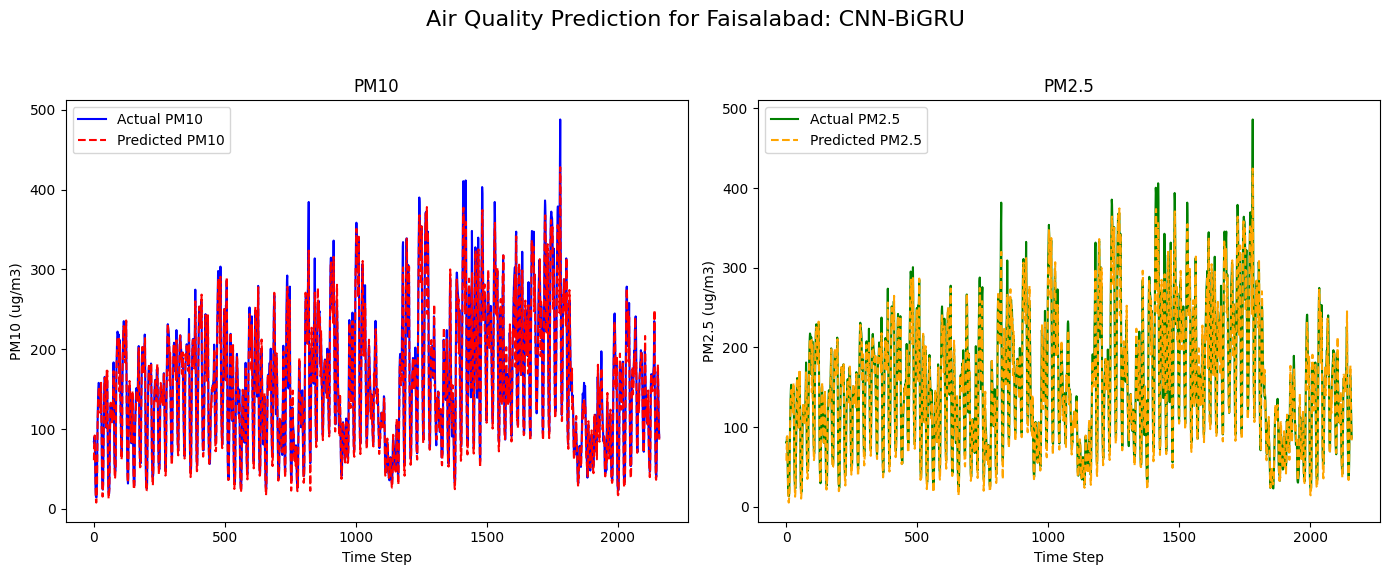

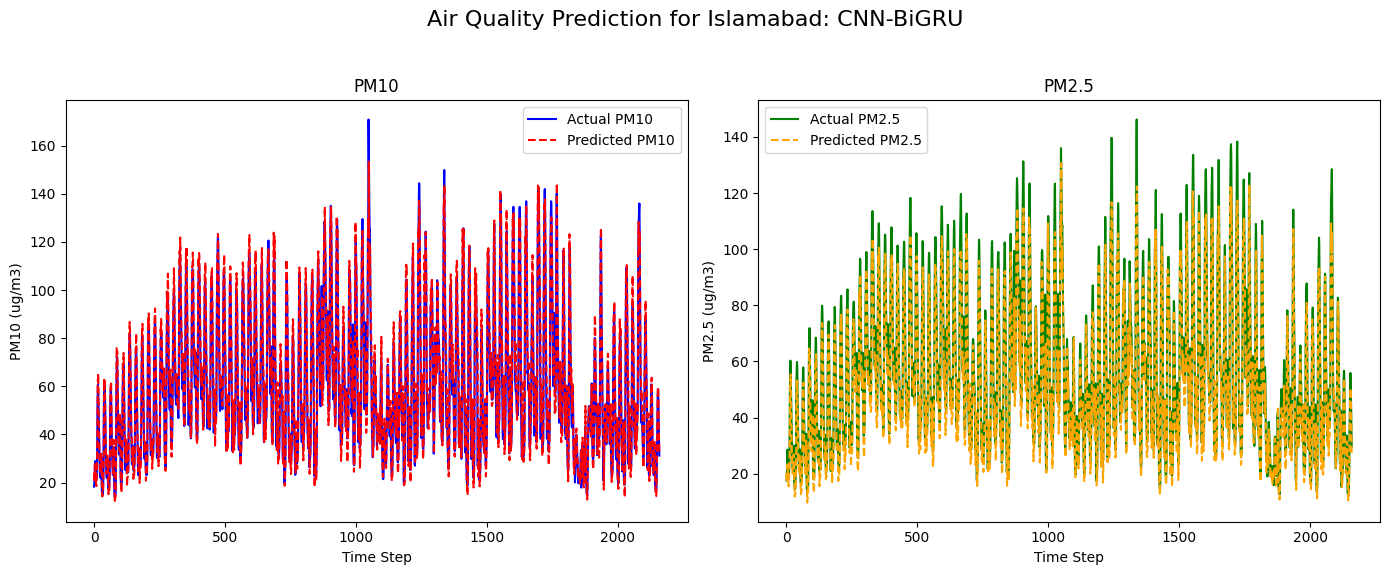

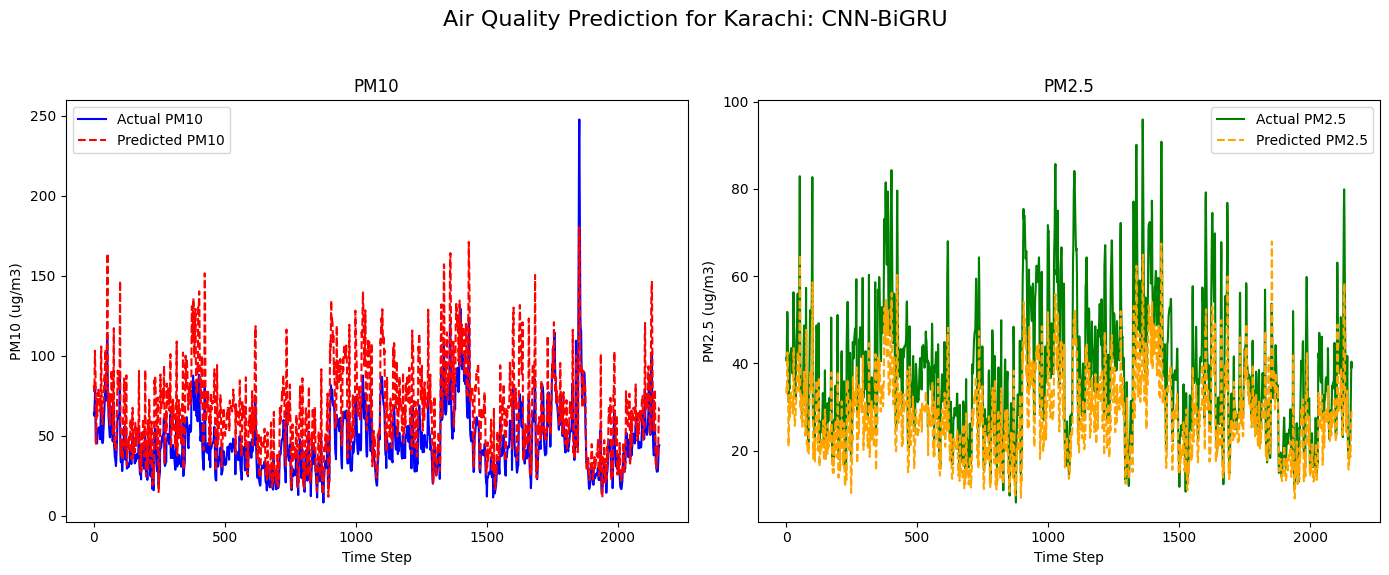

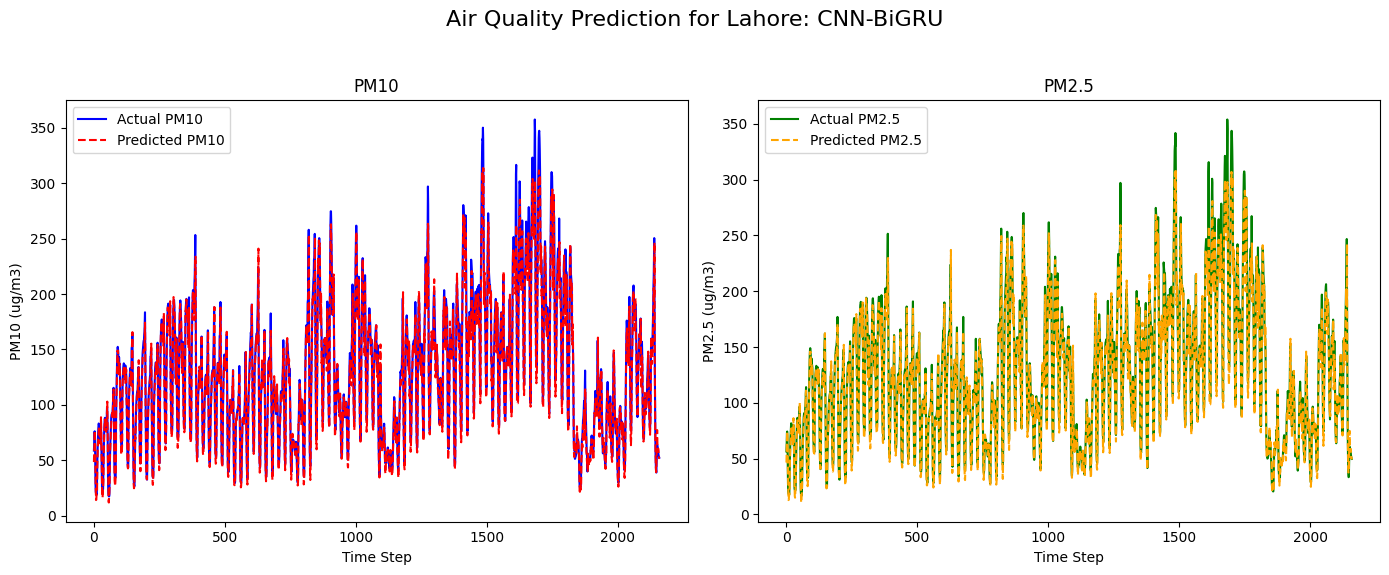

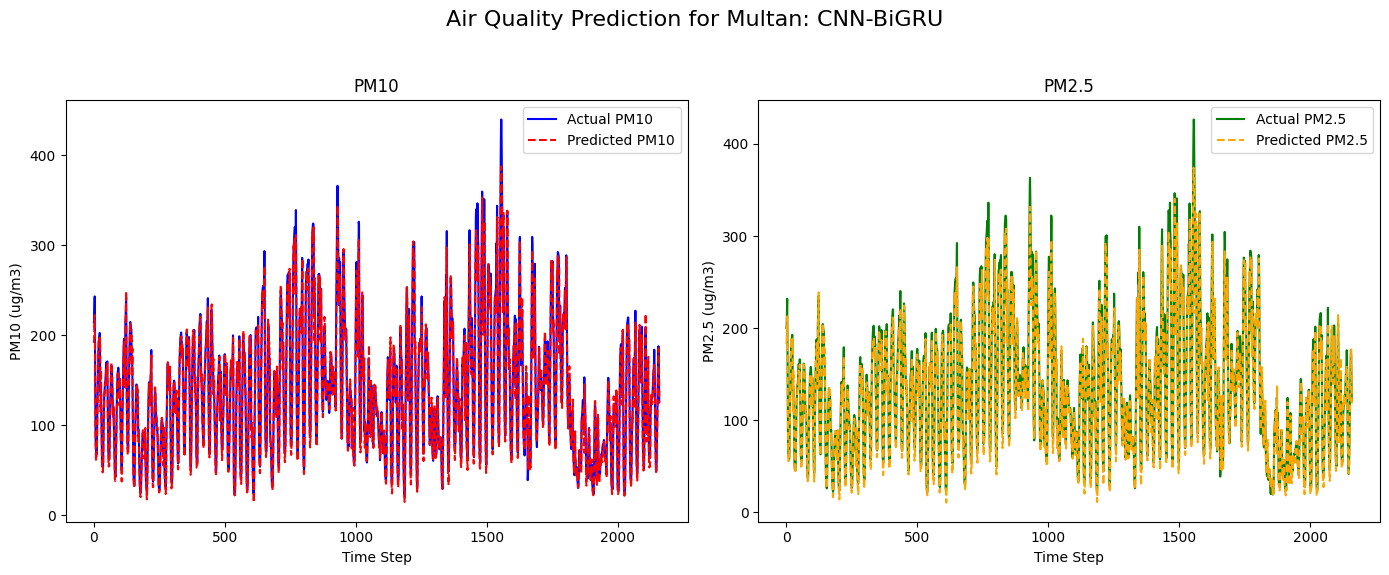

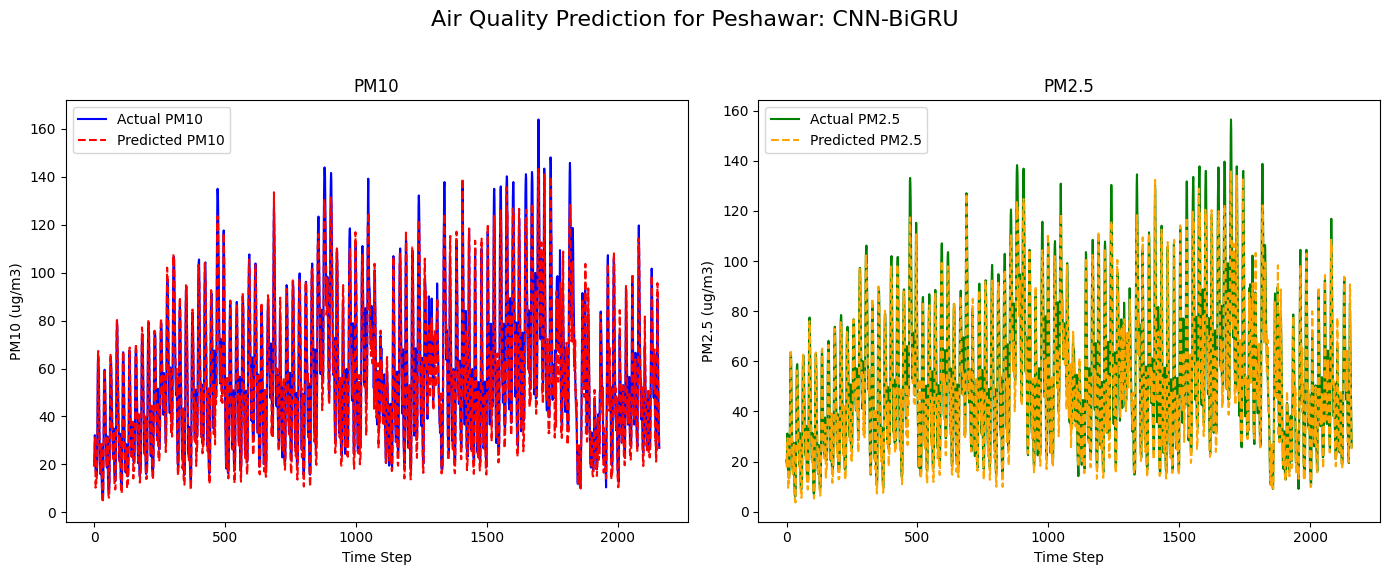

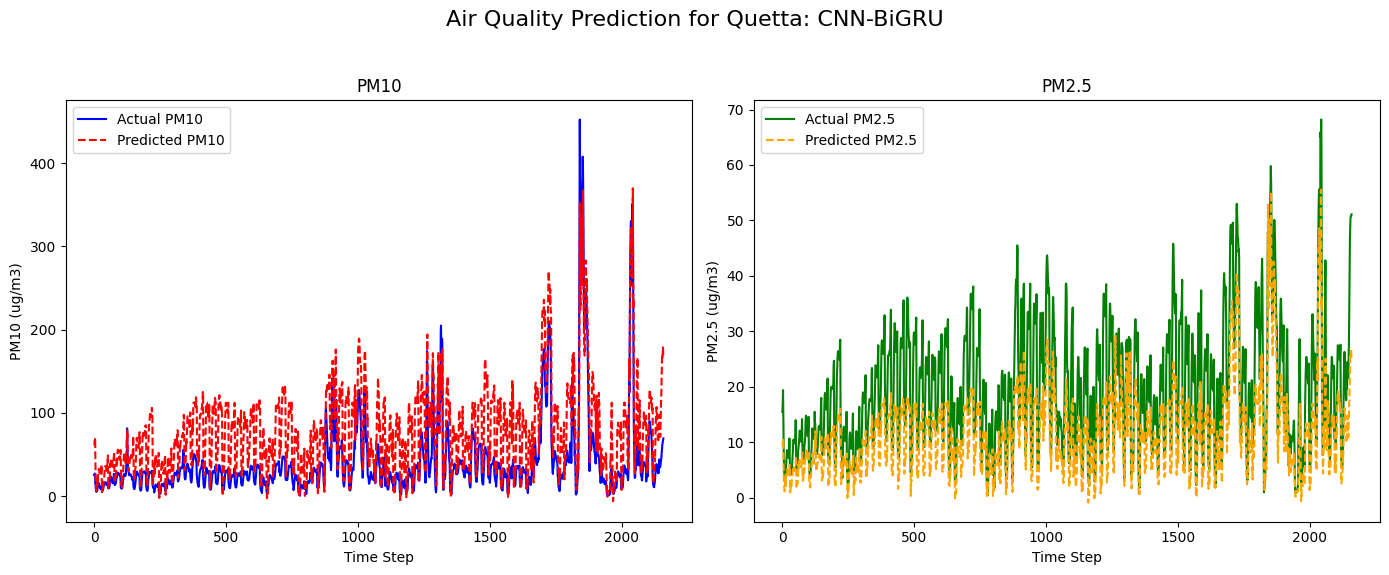

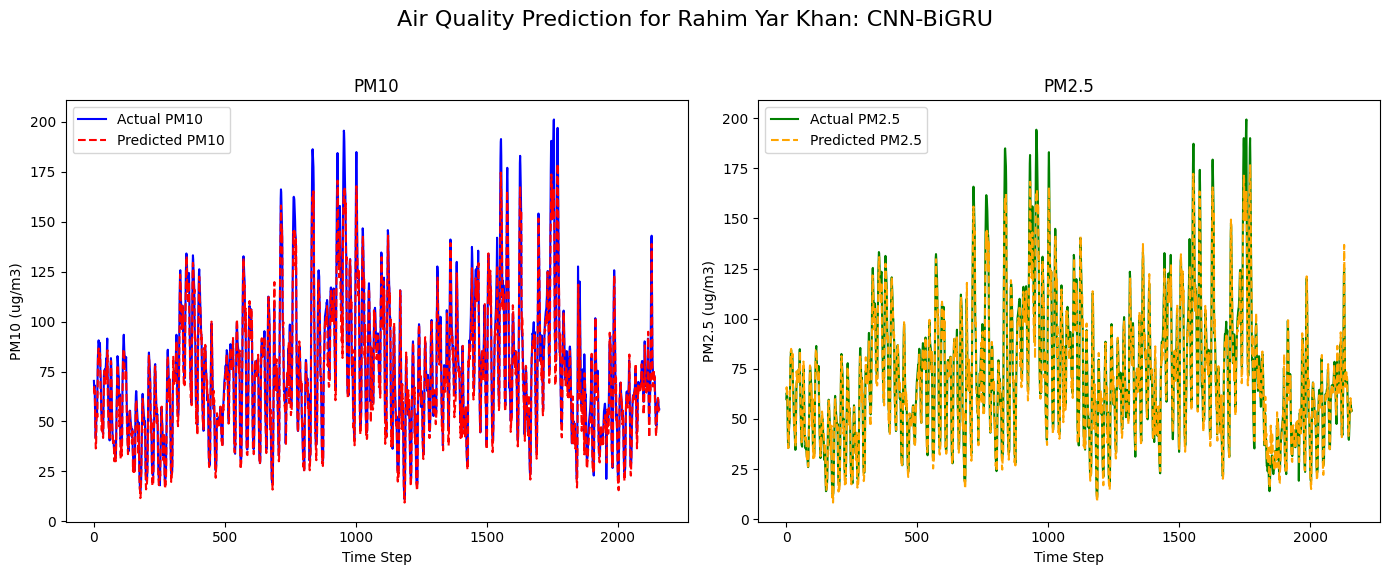

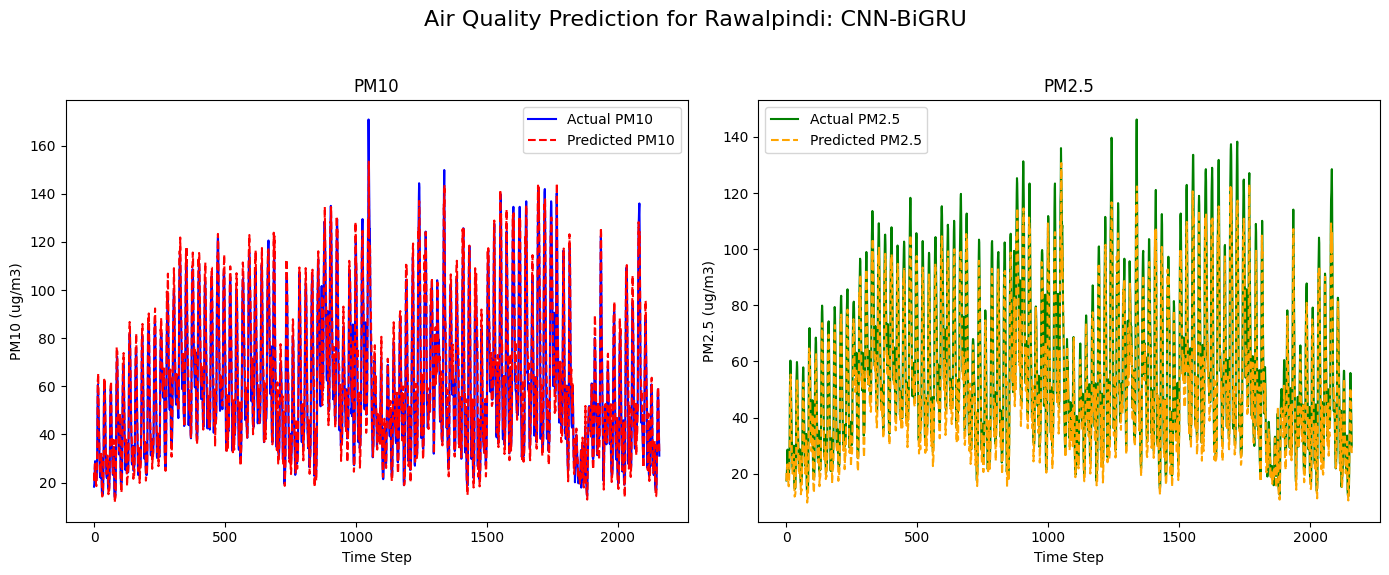

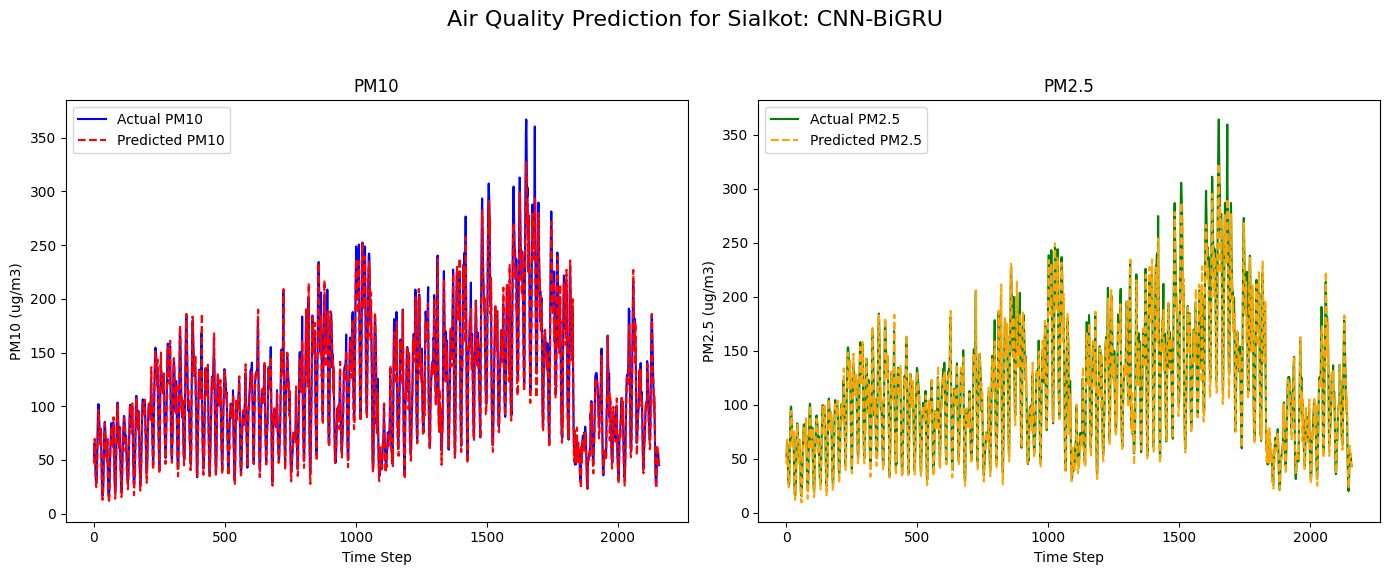

In [ ]:
for city in df['city'].unique():
    city_df = df[df['city'] == city][['pm10', 'pm25']].dropna()

    if len(city_df) < 50: # Skip if data is too small for meaningful prediction
        print(f"Skipping {city}: not enough data.")
        continue

    # Scale data for the current city
    # Re-initialize scaler for each city to avoid data leakage (though often trained once globally)
    local_scaler = MinMaxScaler()
    scaled_data_city = local_scaler.fit_transform(city_df)

    # Create windows for prediction
    X_city, y_city = create_windows(scaled_data_city, time_step=24)

    if len(X_city) == 0:
        print(f"Skipping {city}: not enough data to create sequences.")
        continue

    # Generate PREDICTIONS
    preds_scaled_city = model.predict(X_city, verbose=0)

    # Inverse scaling to get real ug/m3 values
    predictions_inv_city = local_scaler.inverse_transform(preds_scaled_city)
    y_test_inv_city = local_scaler.inverse_transform(y_city)

    # Visualizing Results for the current city
    plt.figure(figsize=(14, 6))
    plt.suptitle(f"Air Quality Prediction for {city}: CNN-BiGRU", fontsize=16)

    # Plot PM10
    plt.subplot(1, 2, 1)
    plt.plot(y_test_inv_city[:, 0], label='Actual PM10', color='blue')
    plt.plot(predictions_inv_city[:, 0], label='Predicted PM10', color='red', linestyle='--')
    plt.title("PM10")
    plt.legend()
    plt.xlabel('Time Step')
    plt.ylabel('PM10 (ug/m3)')

    # Plot PM2.5
    plt.subplot(1, 2, 2)
    plt.plot(y_test_inv_city[:, 1], label='Actual PM2.5', color='green')
    plt.plot(predictions_inv_city[:, 1], label='Predicted PM2.5', color='orange', linestyle='--')
    plt.title("PM2.5")
    plt.legend()
    plt.xlabel('Time Step')
    plt.ylabel('PM2.5 (ug/m3)')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent suptitle overlap
    plt.show()

### Variable Statistics by City

In [3]:
import pandas as pd
from google.colab import files

# Load the dataset specifically for statistics, ensuring 'city' column is present
try:
    df_stats = pd.read_csv("pakistan_air_quality_final_clean.csv")
except FileNotFoundError:
    print("Could not find 'pakistan_air_quality_final_clean.csv' locally. Attempting upload...")
    uploaded = files.upload()
    if uploaded:
        df_stats = pd.read_csv(list(uploaded.keys())[0])
    else:
        print("No file uploaded. Cannot proceed with city-wise statistics.")
        # Optionally raise an error or exit here if df_stats is critical
        raise FileNotFoundError("Dataset file not found or uploaded.")
except Exception as e:
    print(f"An error occurred during file loading: {e}")
    raise

# Rename columns for consistency if necessary, after ensuring df_stats is loaded
df_stats.rename(columns={'pm2_5': 'pm25', 'PM2.5': 'pm25', 'PM10': 'pm10'}, inplace=True)

print('--- PM10 Statistics by City ---')
display(df_stats.groupby('city')['pm10'].describe())

print('\n--- PM2.5 Statistics by City ---')
display(df_stats.groupby('city')['pm25'].describe())

Could not find 'pakistan_air_quality_final_clean.csv' locally. Attempting upload...


Saving pakistan_air_quality_final_clean.csv to pakistan_air_quality_final_clean.csv
--- PM10 Statistics by City ---


,count,mean,std,min,25%,50%,75%,max
city,,,,,,,,
Faisalabad,2184.0,159.076328,83.243447,14.3,93.4,150.40,210.125,488.0
Islamabad,2184.0,58.895009,28.858933,13.9,36.8,51.25,76.800,170.9
Karachi,2184.0,46.423260,21.218382,8.1,32.2,42.50,56.050,247.7
Lahore,2184.0,129.252473,63.113182,17.2,81.0,123.90,168.100,357.6
Multan,2184.0,140.607326,72.152041,22.2,82.0,132.95,186.300,439.6
Peshawar,2184.0,56.426282,30.501093,6.2,31.7,50.55,75.700,163.9
Quetta,2184.0,40.731868,49.674564,0.5,16.9,27.65,41.700,452.6
Rahim Yar Khan,2184.0,76.019551,34.254431,11.0,51.7,71.50,93.400,201.2
Rawalpindi,2184.0,58.895009,28.858933,13.9,36.8,51.25,76.800,170.9



--- PM2.5 Statistics by City ---


,count,mean,std,min,25%,50%,75%,max
city,,,,,,,,
Faisalabad,2184.0,155.736310,82.895447,12.7,90.800,146.7,208.200,486.2
Islamabad,2184.0,56.125504,28.142688,11.9,34.300,49.1,74.075,146.2
Karachi,2184.0,37.708974,15.013471,8.1,26.700,35.8,46.100,95.9
Lahore,2184.0,126.761264,63.113241,16.8,78.000,121.1,166.200,353.9
Multan,2184.0,136.831777,71.652771,19.4,78.900,129.0,182.500,426.5
Peshawar,2184.0,53.729579,30.040706,6.0,29.200,48.7,72.400,156.5
Quetta,2184.0,19.104991,11.036321,0.5,10.300,17.6,26.100,68.2
Rahim Yar Khan,2184.0,72.364927,34.750192,10.9,47.075,68.5,90.800,199.3
Rawalpindi,2184.0,56.125504,28.142688,11.9,34.300,49.1,74.075,146.2
